In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
import ast
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from src.utils.config_loader import load_yaml
from src.utils.path_manager import PathManager
from src.utils.metadata_manager import MetadataManager

In [3]:
data_cfg = load_yaml(
    PROJECT_ROOT
    / "configs"
    / "data_config.yaml"
)

pm = PathManager(
    project_root=PROJECT_ROOT,
    config=data_cfg
)

FEATURE_DIR = pm.get_path(
    data_cfg["dataset"]["feature_dir"]
)

METADATA_DIR = pm.get_path(
    data_cfg["dataset"]["metadata_dir"]
)

In [4]:
feature_inventory = MetadataManager.load_csv(
    METADATA_DIR
    / "feature_inventory.csv"
)

print(len(feature_inventory))

feature_inventory.head()

311


,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,end_time,duration,true_length,padded_length,padding_ratio,raw_file,tensor_file,total_fragments,relative_position,feature_shape
0,s1,clean,train,s1_clean_01.wav,0,0,0,10752,13056,0.672,0.816,0.144,2304,6336,0.636364,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.0,"[4, 257, 19]"
1,s1,clean,train,s1_clean_01.wav,1,1,0,13056,17408,0.816,1.088,0.272,4352,6336,0.313131,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.2,"[4, 257, 35]"
2,s1,clean,train,s1_clean_01.wav,2,2,1,18432,21888,1.152,1.368,0.216,3456,6336,0.454545,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.4,"[4, 257, 28]"
3,s1,clean,train,s1_clean_01.wav,3,3,1,21888,23552,1.368,1.472,0.104,1664,6336,0.737374,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.6,"[4, 257, 14]"
4,s1,clean,train,s1_clean_01.wav,4,4,1,23552,25088,1.472,1.568,0.096,1536,6336,0.757576,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.8,"[4, 257, 13]"


In [5]:
feature_inventory["feature_shape"] = (
    feature_inventory["feature_shape"]
    .apply(ast.literal_eval)
)

feature_inventory["freq_bins"] = (
    feature_inventory["feature_shape"]
    .apply(lambda x: x[1])
)

feature_inventory["time_frames"] = (
    feature_inventory["feature_shape"]
    .apply(lambda x: x[2])
)

feature_inventory[
    ["freq_bins","time_frames"]
].describe()

,freq_bins,time_frames
count,311.0,311.000000
mean,257.0,26.768489
std,0.0,11.438663
min,257.0,11.000000
25%,257.0,18.000000
50%,257.0,24.000000
75%,257.0,33.000000
max,257.0,67.000000


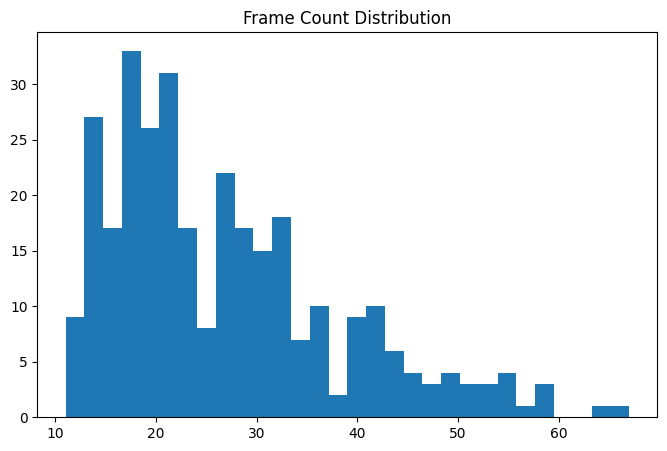

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_inventory["time_frames"],
    bins=30
)

plt.title(
    "Frame Count Distribution"
)

plt.show()

In [7]:
all_mag = []

for _, row in feature_inventory.iterrows():

    folder = (

        FEATURE_DIR

        / row["speaker"]

        / Path(
            row["source_file"]
        ).stem

        / f"fragment_{int(row['fragment_id']):03d}"
    )

    mag = np.load(
        folder / "magnitude.npy"
    )

    mean_spec = mag.mean(axis=1)

    all_mag.append(mean_spec)

all_mag = np.array(
    all_mag
)

print(all_mag.shape)

(311, 257)


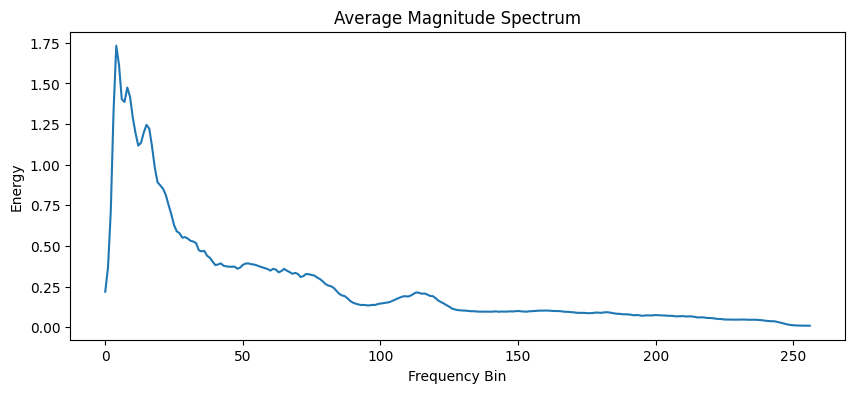

In [8]:
avg_mag = all_mag.mean(axis=0)

plt.figure(figsize=(10,4))

plt.plot(avg_mag)

plt.title(
    "Average Magnitude Spectrum"
)

plt.xlabel(
    "Frequency Bin"
)

plt.ylabel(
    "Energy"
)

plt.show()

In [9]:
clean_mag = []
noisy_mag = []

for _, row in feature_inventory.iterrows():

    folder = (

        FEATURE_DIR

        / row["speaker"]

        / Path(
            row["source_file"]
        ).stem

        / f"fragment_{int(row['fragment_id']):03d}"
    )

    mag = np.load(
        folder / "magnitude.npy"
    )

    mean_spec = mag.mean(axis=1)

    if row["condition"] == "clean":
        clean_mag.append(mean_spec)

    else:
        noisy_mag.append(mean_spec)

clean_mag = np.array(clean_mag)
noisy_mag = np.array(noisy_mag)

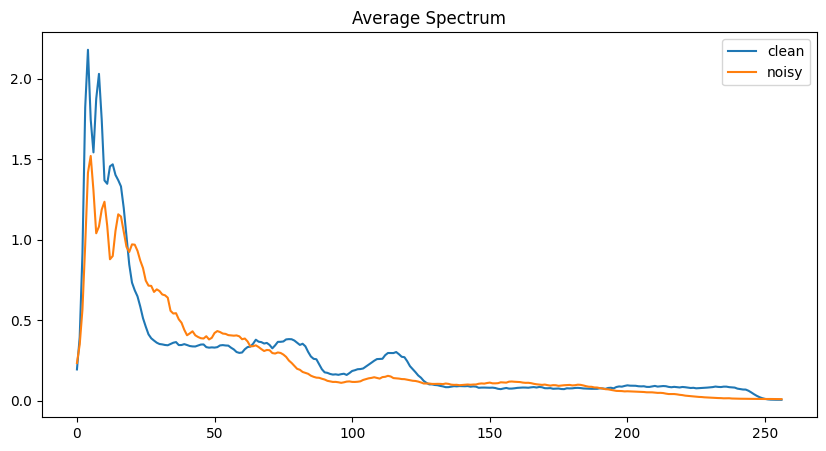

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    clean_mag.mean(axis=0),
    label="clean"
)

plt.plot(
    noisy_mag.mean(axis=0),
    label="noisy"
)

plt.legend()

plt.title(
    "Average Spectrum"
)

plt.show()

In [11]:
X_mag = []

for _, row in feature_inventory.iterrows():

    folder = (

        FEATURE_DIR

        / row["speaker"]

        / Path(
            row["source_file"]
        ).stem

        / f"fragment_{int(row['fragment_id']):03d}"
    )

    mag = np.load(
        folder / "magnitude.npy"
    )

    X_mag.append(
        mag.mean(axis=1)
    )

X_mag = np.array(
    X_mag
)

print(X_mag.shape)

(311, 257)


In [12]:
X_scaled = StandardScaler().fit_transform(
    X_mag
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

In [13]:
colors = feature_inventory[
    "condition"
].map({

    "clean":"blue",
    "noisy":"red"
})

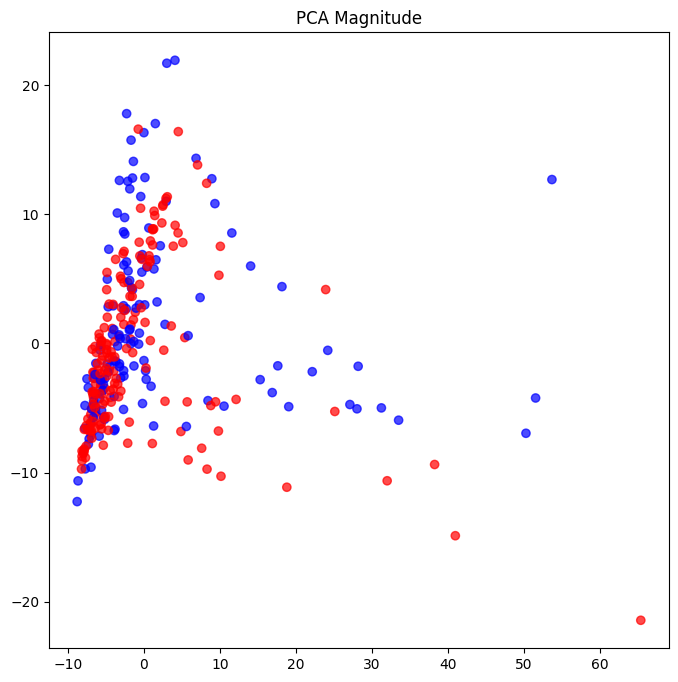

In [14]:
plt.figure(figsize=(8,8))

plt.scatter(

    X_pca[:,0],
    X_pca[:,1],

    c=colors,

    alpha=0.7
)

plt.title(
    "PCA Magnitude"
)

plt.show()

In [15]:
X_if = []

for _, row in feature_inventory.iterrows():

    folder = (

        FEATURE_DIR

        / row["speaker"]

        / Path(
            row["source_file"]
        ).stem

        / f"fragment_{int(row['fragment_id']):03d}"
    )

    if_map = np.load(
        folder / "if.npy"
    )

    X_if.append(
        if_map.mean(axis=1)
    )

X_if = np.array(
    X_if
)

In [16]:
X_scaled = StandardScaler().fit_transform(
    X_if
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

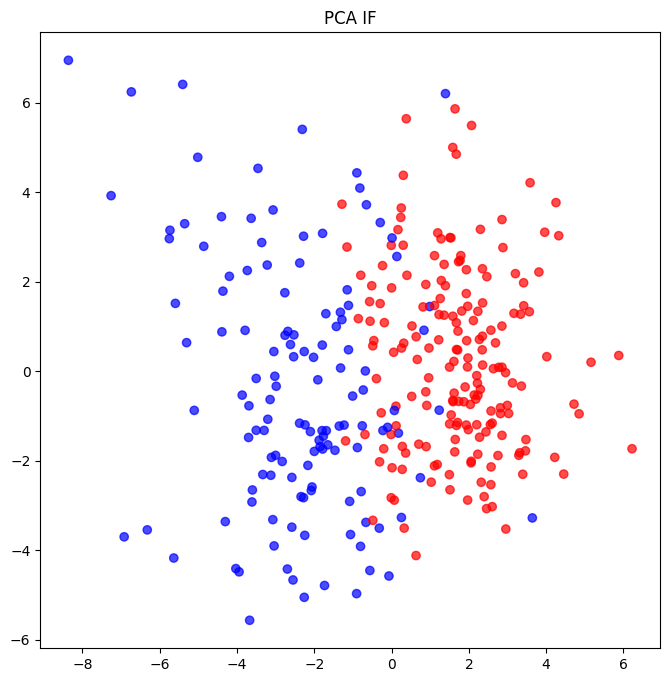

In [17]:
plt.figure(figsize=(8,8))

plt.scatter(

    X_pca[:,0],
    X_pca[:,1],

    c=colors,

    alpha=0.7
)

plt.title(
    "PCA IF"
)

plt.show()

In [18]:
X_all = []

for _, row in feature_inventory.iterrows():

    folder = (

        FEATURE_DIR

        / row["speaker"]

        / Path(
            row["source_file"]
        ).stem

        / f"fragment_{int(row['fragment_id']):03d}"
    )

    feat = np.load(
        folder / "features.npy"
    )

    vec = feat.mean(axis=2).reshape(-1)

    X_all.append(vec)

X_all = np.array(
    X_all
)

print(X_all.shape)

(311, 1028)


In [19]:
X_scaled = StandardScaler().fit_transform(
    X_all
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

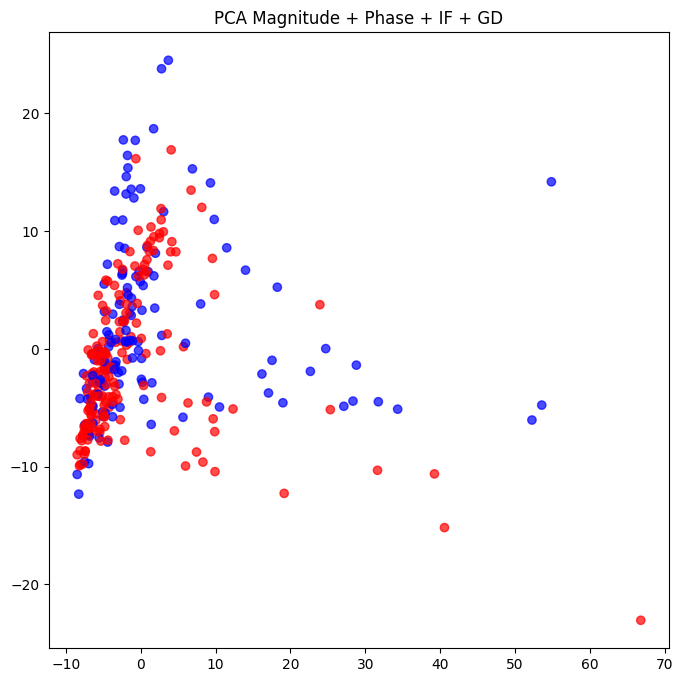

In [20]:
plt.figure(figsize=(8,8))

plt.scatter(

    X_pca[:,0],
    X_pca[:,1],

    c=colors,

    alpha=0.7
)

plt.title(
    "PCA Magnitude + Phase + IF + GD"
)

plt.show()

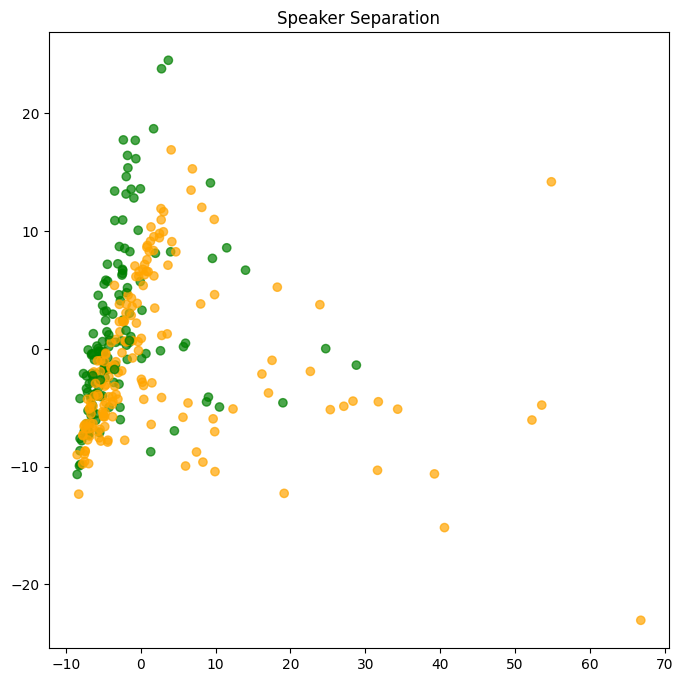

In [22]:
speaker_colors = feature_inventory[
    "speaker"
].map({

    "s1":"green",
    "s2":"orange"
})

plt.figure(figsize=(8,8))

plt.scatter(

    X_pca[:,0],
    X_pca[:,1],

    c=speaker_colors,

    alpha=0.7
)

plt.title(
    "Speaker Separation"
)

plt.show()